In [1]:
# Libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time


In [4]:
# Download mini subset of ImageNet (10 classes)
import tensorflow_datasets as tfds
dataset_name = "imagenette/160px"  # Lightweight 10-class ImageNet subset

# Load train + validation only
(train_ds, val_ds_full), ds_info = tfds.load(
    dataset_name,
    split=["train", "validation"],
    as_supervised=True,
    with_info=True
)

# Manually create test split from validation (50/50)
val_ds = val_ds_full.take(len(val_ds_full) // 2)
test_ds = val_ds_full.skip(len(val_ds_full) // 2)


In [5]:
# Preprocessing
IMG_SIZE = 299  # Required by Inception architectures
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train = train_ds.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val   = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test  = test_ds.map(preprocess).batch(BATCH_SIZE).prefetch(AUTOTUNE)

NUM_CLASSES = ds_info.features["label"].num_classes


In [6]:
# Model building
def build_model(model_name):
    base = tf.keras.applications.__dict__[model_name](
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        weights="imagenet"
    )

    base.trainable = False  # For fast demo training

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [7]:
# Graph plotting
def plot_history(history, title):
    plt.figure(figsize=(12,5))

    # accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="train")
    plt.plot(history.history['val_accuracy'], label="val")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="train")
    plt.plot(history.history['val_loss'], label="val")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()


In [8]:
# Printing metrics
def evaluate_model(model, test_dataset):
    y_true = []
    y_pred = []
    latencies = []

    for images, labels in test_dataset:
        start_time = time.time()
        preds = model.predict(images, verbose=0)
        end_time = time.time()

        batch_latency = (end_time - start_time) / len(images)
        latencies.append(batch_latency)

        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    latency_ms = np.mean(latencies) * 1000
    throughput = 1 / np.mean(latencies)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "latency_ms": latency_ms,
        "throughput": throughput,
        "y_true": y_true,
        "y_pred": y_pred
    }


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 97s 189ms/step - accuracy: 0.8931 - loss: 0.4370 - val_accuracy: 0.9720 - val_loss: 0.0730
Epoch 2/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 50s 121ms/step - accuracy: 0.9901 - loss: 0.0437 - val_accuracy: 0.9720 - val_loss: 0.0642
Epoch 3/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 51s 124ms/step - accuracy: 0.9922 - loss: 0.0319 - val_accuracy: 0.9840 - val_loss: 0.0538
Epoch 4/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 52s 125ms/step - accuracy: 0.9935 - loss: 0.0245 - val_accuracy: 0.9760 - val_loss: 0.0667
Epoch 5/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 51s 124ms/step - accuracy: 0.9957 - loss: 0.0170 - val_accuracy: 0.9840 - val_loss: 0.0552


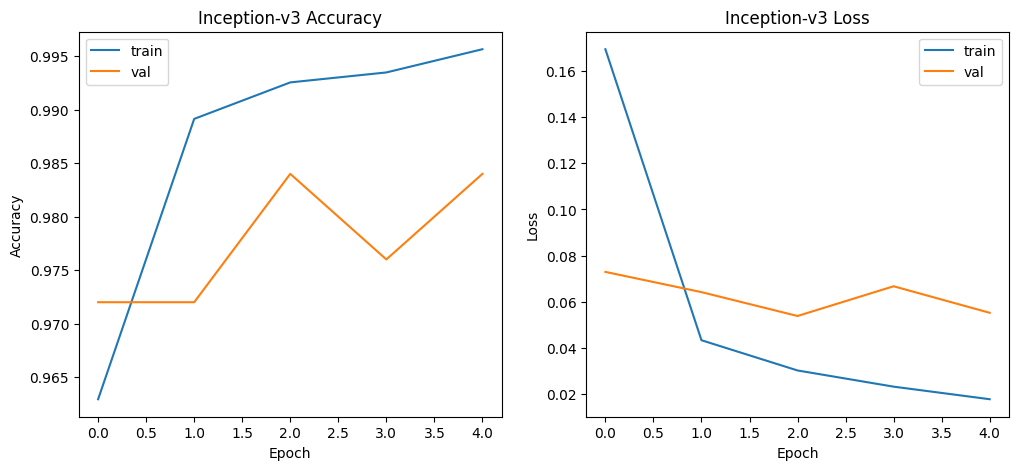

Inception-v3 Metrics:
accuracy: 0.98
precision: 0.980415750915751
recall: 0.9786666666666667
f1: 0.9792843737703384
latency_ms: 62.31246523272533
throughput: 16.04815338737102


In [9]:
# Inception-v3
model_iv3 = build_model("InceptionV3")

history_iv3 = model_iv3.fit(
    train,
    validation_data=val,
    epochs=5
)

plot_history(history_iv3, "Inception-v3")

results_iv3 = evaluate_model(model_iv3, test)
print("Inception-v3 Metrics:")
for k,v in results_iv3.items():
    if k not in ["y_true", "y_pred"]:
        print(f"{k}: {v}")


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Epoch 1/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 184s 376ms/step - accuracy: 0.9260 - loss: 0.3794 - val_accuracy: 0.9800 - val_loss: 0.0575
Epoch 2/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 117s 289ms/step - accuracy: 0.9929 - loss: 0.0311 - val_accuracy: 0.9800 - val_loss: 0.0614
Epoch 3/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 145s 296ms/step - accuracy: 0.9938 - loss: 0.0233 - val_accuracy: 0.9840 - val_loss: 0.0495
Epoch 4/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 119s 293ms/step - accuracy: 0.9957 - loss: 0.0167 - val_accuracy: 0.9880 - val_loss: 0.0455
Epoch 5/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 119s 294ms/step - accuracy: 0.9970 - loss: 0.0128 - val_accuracy: 0.9800 - val_loss: 0.0529


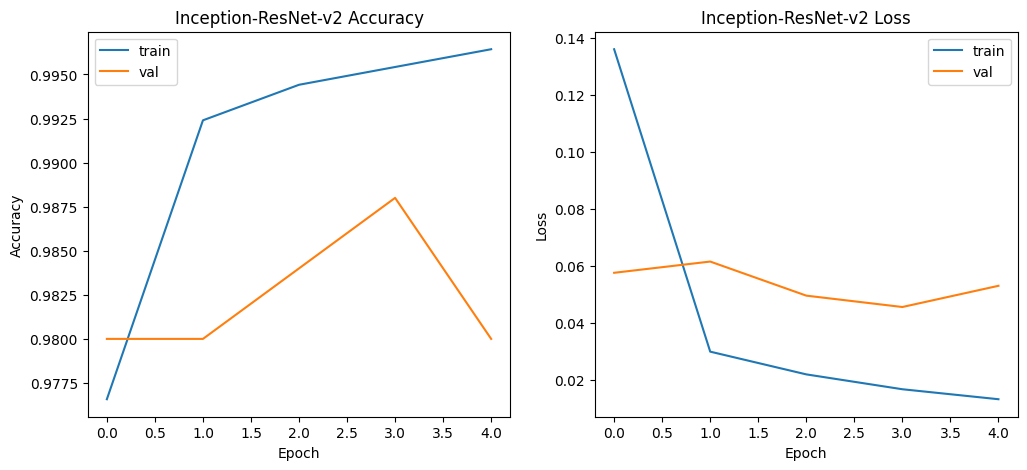


Inception-ResNet-v2 Metrics:
accuracy: 0.988
precision: 0.9884285714285713
recall: 0.9868333333333335
f1: 0.9874492397167168
latency_ms: 117.51732867784226
throughput: 8.509383350104594


In [10]:
model_irnv2 = build_model("InceptionResNetV2")

history_irnv2 = model_irnv2.fit(
    train,
    validation_data=val,
    epochs=5
)

plot_history(history_irnv2, "Inception-ResNet-v2")

results_irnv2 = evaluate_model(model_irnv2, test)
print("\nInception-ResNet-v2 Metrics:")
for k,v in results_irnv2.items():
    if k not in ["y_true", "y_pred"]:
        print(f"{k}: {v}")